# Phase 4C — IDSSE External Replication

This notebook reports the completed execution of the frozen Phase 4C external-replication protocol on the seven designated IDSSE/DFL matches. It reads the immutable execution outputs produced by `src/phase4c_idsse_external_replication.py`; it does not reconstruct samples or rerun the 10,000-resample bootstrap.

The tested object remains a geometric primitive: accumulated focal-defender movement relative to the leave-one-out defending-outfield centroid. The analysis does **not** validate tactical response, attacker influence, responsibility, relational reconfiguration, gravity, or value.

In [1]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
OUT = ROOT / 'outputs' / 'phase4c'
FIG = ROOT / 'figures' / 'phase4c'

classification = json.loads((OUT / 'classification.json').read_text())
gate = json.loads((OUT / 'mapping_gate.json').read_text())
manifest = json.loads((OUT / 'execution_manifest.json').read_text())
classification

{'category': 'A',
 'label': 'strong external replication',
 'reasons': [],
 'usable_matches': 7,
 'core_replicating_matches': 7,
 'common_translation_pass': True,
 'protocol_sha256_before_execution': '6e1711ba681bce3c843cde9803758ca68428f2a84e6b25454d9d866cee5dea59'}

## Outcome-blind mapping and support gate

All seven designated matches passed the frozen usability gate. The field mapping, observation-validity clarification, event-state construction, exclusions, and support counts are documented in `docs/phase4c_idsse_mapping_audit.md`. No focal-departure outcome was used to choose or revise the mapping.

In [2]:
support = pd.read_csv(OUT / 'mapping_interval_support.csv')
support

,match_id,period,sequence,start_time_utc,end_time_utc,attacking_team_id,defending_team_id,complete_defending_outfield_count,complete_focal_ids,eligible,exclusion_reason
0,J03WMX,firstHalf,0,2023-05-27T13:30:17.230000+00:00,2023-05-27T13:30:22.230000+00:00,DFL-CLU-00000G,DFL-CLU-000008,10,DFL-OBJ-00012X|DFL-OBJ-000270|DFL-OBJ-0002BO|D...,True,NaN
1,J03WMX,firstHalf,1,2023-05-27T13:30:22.230000+00:00,2023-05-27T13:30:27.230000+00:00,DFL-CLU-00000G,DFL-CLU-000008,10,DFL-OBJ-00012X|DFL-OBJ-000270|DFL-OBJ-0002BO|D...,True,NaN
2,J03WMX,firstHalf,2,2023-05-27T13:30:27.230000+00:00,2023-05-27T13:30:32.230000+00:00,DFL-CLU-00000G,DFL-CLU-000008,10,DFL-OBJ-00012X|DFL-OBJ-000270|DFL-OBJ-0002BO|D...,True,NaN
3,J03WMX,firstHalf,3,2023-05-27T13:30:32.230000+00:00,2023-05-27T13:30:37.230000+00:00,NaN,NaN,0,NaN,False,possession_or_open_play
4,J03WMX,firstHalf,4,2023-05-27T13:30:37.230000+00:00,2023-05-27T13:30:42.230000+00:00,DFL-CLU-00000G,DFL-CLU-000008,10,DFL-OBJ-00012X|DFL-OBJ-000270|DFL-OBJ-0002BO|D...,True,NaN
...,...,...,...,...,...,...,...,...,...,...,...
7999,J03WR9,secondHalf,621,2022-11-11T19:25:13.020000+00:00,2022-11-11T19:25:18.020000+00:00,NaN,NaN,0,NaN,False,possession_or_open_play
8000,J03WR9,secondHalf,622,2022-11-11T19:25:18.020000+00:00,2022-11-11T19:25:23.020000+00:00,NaN,NaN,0,NaN,False,possession_or_open_play
8001,J03WR9,secondHalf,623,2022-11-11T19:25:23.020000+00:00,2022-11-11T19:25:28.020000+00:00,NaN,NaN,0,NaN,False,possession_or_open_play
8002,J03WR9,secondHalf,624,2022-11-11T19:25:28.020000+00:00,2022-11-11T19:25:33.020000+00:00,NaN,NaN,0,NaN,False,possession_or_open_play


## Primary geometric result

Every usable match met the frozen core replication criteria. Across matches, median focal departure ranged from approximately 4.42 to 5.23 m. These magnitudes are externally replicated geometry, not evidence that the focal player tactically responded to or was influenced by an attacker.

In [3]:
match_summary = pd.read_csv(OUT / 'match_summary.csv')
activity = pd.read_csv(OUT / 'primary_activity_correlations.csv')
display(match_summary)
display(activity)

,match_id,observations,intervals,median_m,iqr_m,p10_m,p25_m,p75_m,p90_m,numerical_zero_fraction,finite,nonnegative,rho__focal_absolute_path_m,rho__full_defending_outfield_centroid_path_m,rho__sum_defending_outfield_paths_m,rho__ball_path_m,misaligned_pass,misaligned_material_contradiction,sensitivity_pass,core_replicating
0,J03WMX,6949,695,5.141801,4.394554,2.116396,3.312894,7.707448,10.941797,0.0,True,True,0.710138,0.522643,0.588305,0.467134,True,False,True,True
1,J03WN1,5436,574,4.424796,3.787438,1.882989,2.874052,6.661489,9.800164,0.0,True,True,0.643927,0.432589,0.546998,0.441151,True,False,True,True
2,J03WOH,6116,612,4.934149,4.297547,2.009157,3.191594,7.489140,10.640885,0.0,True,True,0.686164,0.495729,0.570176,0.456833,True,False,True,True
3,J03WOY,6345,635,4.928713,4.196908,2.102944,3.249826,7.446734,10.710036,0.0,True,True,0.670913,0.492884,0.565018,0.475302,True,False,True,True
4,J03WPY,7077,708,4.770319,4.217778,1.902219,3.027646,7.245424,10.634236,0.0,True,True,0.702498,0.509056,0.586417,0.443145,True,False,True,True
5,J03WQQ,6298,640,5.230534,4.532554,2.178042,3.350866,7.883420,11.126590,0.0,True,True,0.688276,0.456958,0.542317,0.410473,True,False,True,True
6,J03WR9,6558,656,5.149486,4.186639,2.266991,3.399136,7.585775,10.615247,0.0,True,True,0.659597,0.434483,0.524415,0.394663,True,False,True,True


,match_id,seconds,smoothing_frames,activity_variable,spearman_rho
0,J03WMX,5,7,focal_absolute_path_m,0.710138
1,J03WMX,5,7,full_defending_outfield_centroid_path_m,0.522643
2,J03WMX,5,7,sum_defending_outfield_paths_m,0.588305
3,J03WMX,5,7,ball_path_m,0.467134
4,J03WN1,5,7,focal_absolute_path_m,0.643927
5,J03WN1,5,7,full_defending_outfield_centroid_path_m,0.432589
6,J03WN1,5,7,sum_defending_outfield_paths_m,0.546998
7,J03WN1,5,7,ball_path_m,0.441151
8,J03WOH,5,7,focal_absolute_path_m,0.686164
9,J03WOH,5,7,full_defending_outfield_centroid_path_m,0.495729


## Controls, sensitivity, and uncertainty

The observed-trajectory common-translation control passed at all three fixed smoothing settings. The frozen time-misalignment control passed in all seven matches. Each match passed all 9/9 fixed sensitivity cells, and the interval-cluster bootstrap retained positive activity-association estimates. Strong positive activity relationships remain important counterevidence against treating focal departure as an activity-free or tactical construct.

In [4]:
control = pd.read_csv(OUT / 'primary_misaligned_control.csv')
translation = pd.read_csv(OUT / 'common_translation_control.csv')
sensitivity = pd.read_csv(OUT / 'sensitivity_match_results.csv')
bootstrap = pd.read_csv(OUT / 'bootstrap_uncertainty.csv')
display(control)
display(translation)
display(sensitivity)
display(bootstrap)

,match_id,seconds,smoothing_frames,eligible_interval_support_fraction,supported_intervals,paired_focal_observations,paired_median_difference_m,fraction_misaligned_greater,fraction_misaligned_nonnegative,pass,material_contradiction,classification
0,J03WMX,5,7,0.946763,658,6579,2.361593,0.773674,0.773674,True,False,pass
1,J03WN1,5,7,0.958188,550,5206,1.137209,0.717441,0.717441,True,False,pass
2,J03WOH,5,7,0.949346,581,5806,2.176332,0.777472,0.777472,True,False,pass
3,J03WOY,5,7,0.955906,607,6065,2.277286,0.781204,0.781204,True,False,pass
4,J03WPY,5,7,0.961864,681,6807,1.794484,0.760688,0.760688,True,False,pass
5,J03WQQ,5,7,0.954688,611,6014,2.267225,0.775357,0.775357,True,False,pass
6,J03WR9,5,7,0.939024,616,6158,2.941064,0.801397,0.801397,True,False,pass


,smoothing_frames,maximum_focal_relative_path_m,pass
0,5,7.113080e-13,True
1,7,7.541834e-13,True
2,9,7.240574e-13,True


,match_id,consistent_settings,any_material_activity_reversal,any_material_control_contradiction,primary_setting_pass,sensitivity_pass
0,J03WMX,9,False,False,True,True
1,J03WN1,9,False,False,True,True
2,J03WOH,9,False,False,True,True
3,J03WOY,9,False,False,True,True
4,J03WPY,9,False,False,True,True
5,J03WQQ,9,False,False,True,True
6,J03WR9,9,False,False,True,True


,match_id,metric,bootstrap_low,bootstrap_high,resamples
0,J03WMX,median_m,4.964525,5.326380,10000
1,J03WMX,rho__focal_absolute_path_m,0.686615,0.731808,10000
2,J03WMX,rho__full_defending_outfield_centroid_path_m,0.490374,0.551978,10000
3,J03WMX,rho__sum_defending_outfield_paths_m,0.559797,0.613894,10000
4,J03WMX,rho__ball_path_m,0.436999,0.494999,10000
5,J03WN1,median_m,4.267866,4.581166,10000
6,J03WN1,rho__focal_absolute_path_m,0.613674,0.672888,10000
7,J03WN1,rho__full_defending_outfield_centroid_path_m,0.386909,0.476018,10000
8,J03WN1,rho__sum_defending_outfield_paths_m,0.509872,0.580813,10000
9,J03WN1,rho__ball_path_m,0.402774,0.476713,10000


## Activity-bin transport diagnostic

The frozen Metrica focal-by-centroid activity grid was computable and all nine cells were occupied in every IDSSE match. Occupancy was skewed toward the low physical-cut cells, so this supports coverage and transport feasibility—not identical distributional transport. IDSSE within-match terciles remain descriptive only.

In [5]:
transport = pd.read_csv(OUT / 'metrica_activity_cut_transport.csv')
terciles = pd.read_csv(OUT / 'idsse_activity_terciles_descriptive.csv')
display(transport)
display(terciles)

,match_id,metrica_bin__focal_absolute_path_m,metrica_bin__full_defending_outfield_centroid_path_m,observations,median_m
0,J03WMX,high,high,1064,7.902572
1,J03WMX,high,low,148,12.686763
2,J03WMX,high,middle,363,10.332172
3,J03WMX,low,high,97,7.950233
4,J03WMX,low,low,3492,3.645649
...,...,...,...,...,...
58,J03WR9,low,low,3135,3.658159
59,J03WR9,low,middle,416,5.190320
60,J03WR9,middle,high,298,5.786385
61,J03WR9,middle,low,725,7.221298


,match_id,idsse_tercile__focal_absolute_path_m,idsse_tercile__full_defending_outfield_centroid_path_m,observations,median_m
0,J03WMX,low,low,1722,2.732377
1,J03WMX,low,middle,569,3.821353
2,J03WMX,low,high,25,8.741044
3,J03WMX,middle,low,556,6.153568
4,J03WMX,middle,middle,1260,4.827423
...,...,...,...,...,...
58,J03WR9,middle,middle,1080,4.328576
59,J03WR9,middle,high,504,5.534804
60,J03WR9,high,low,87,11.333753
61,J03WR9,high,middle,498,8.706064


## Soccer-readable summaries

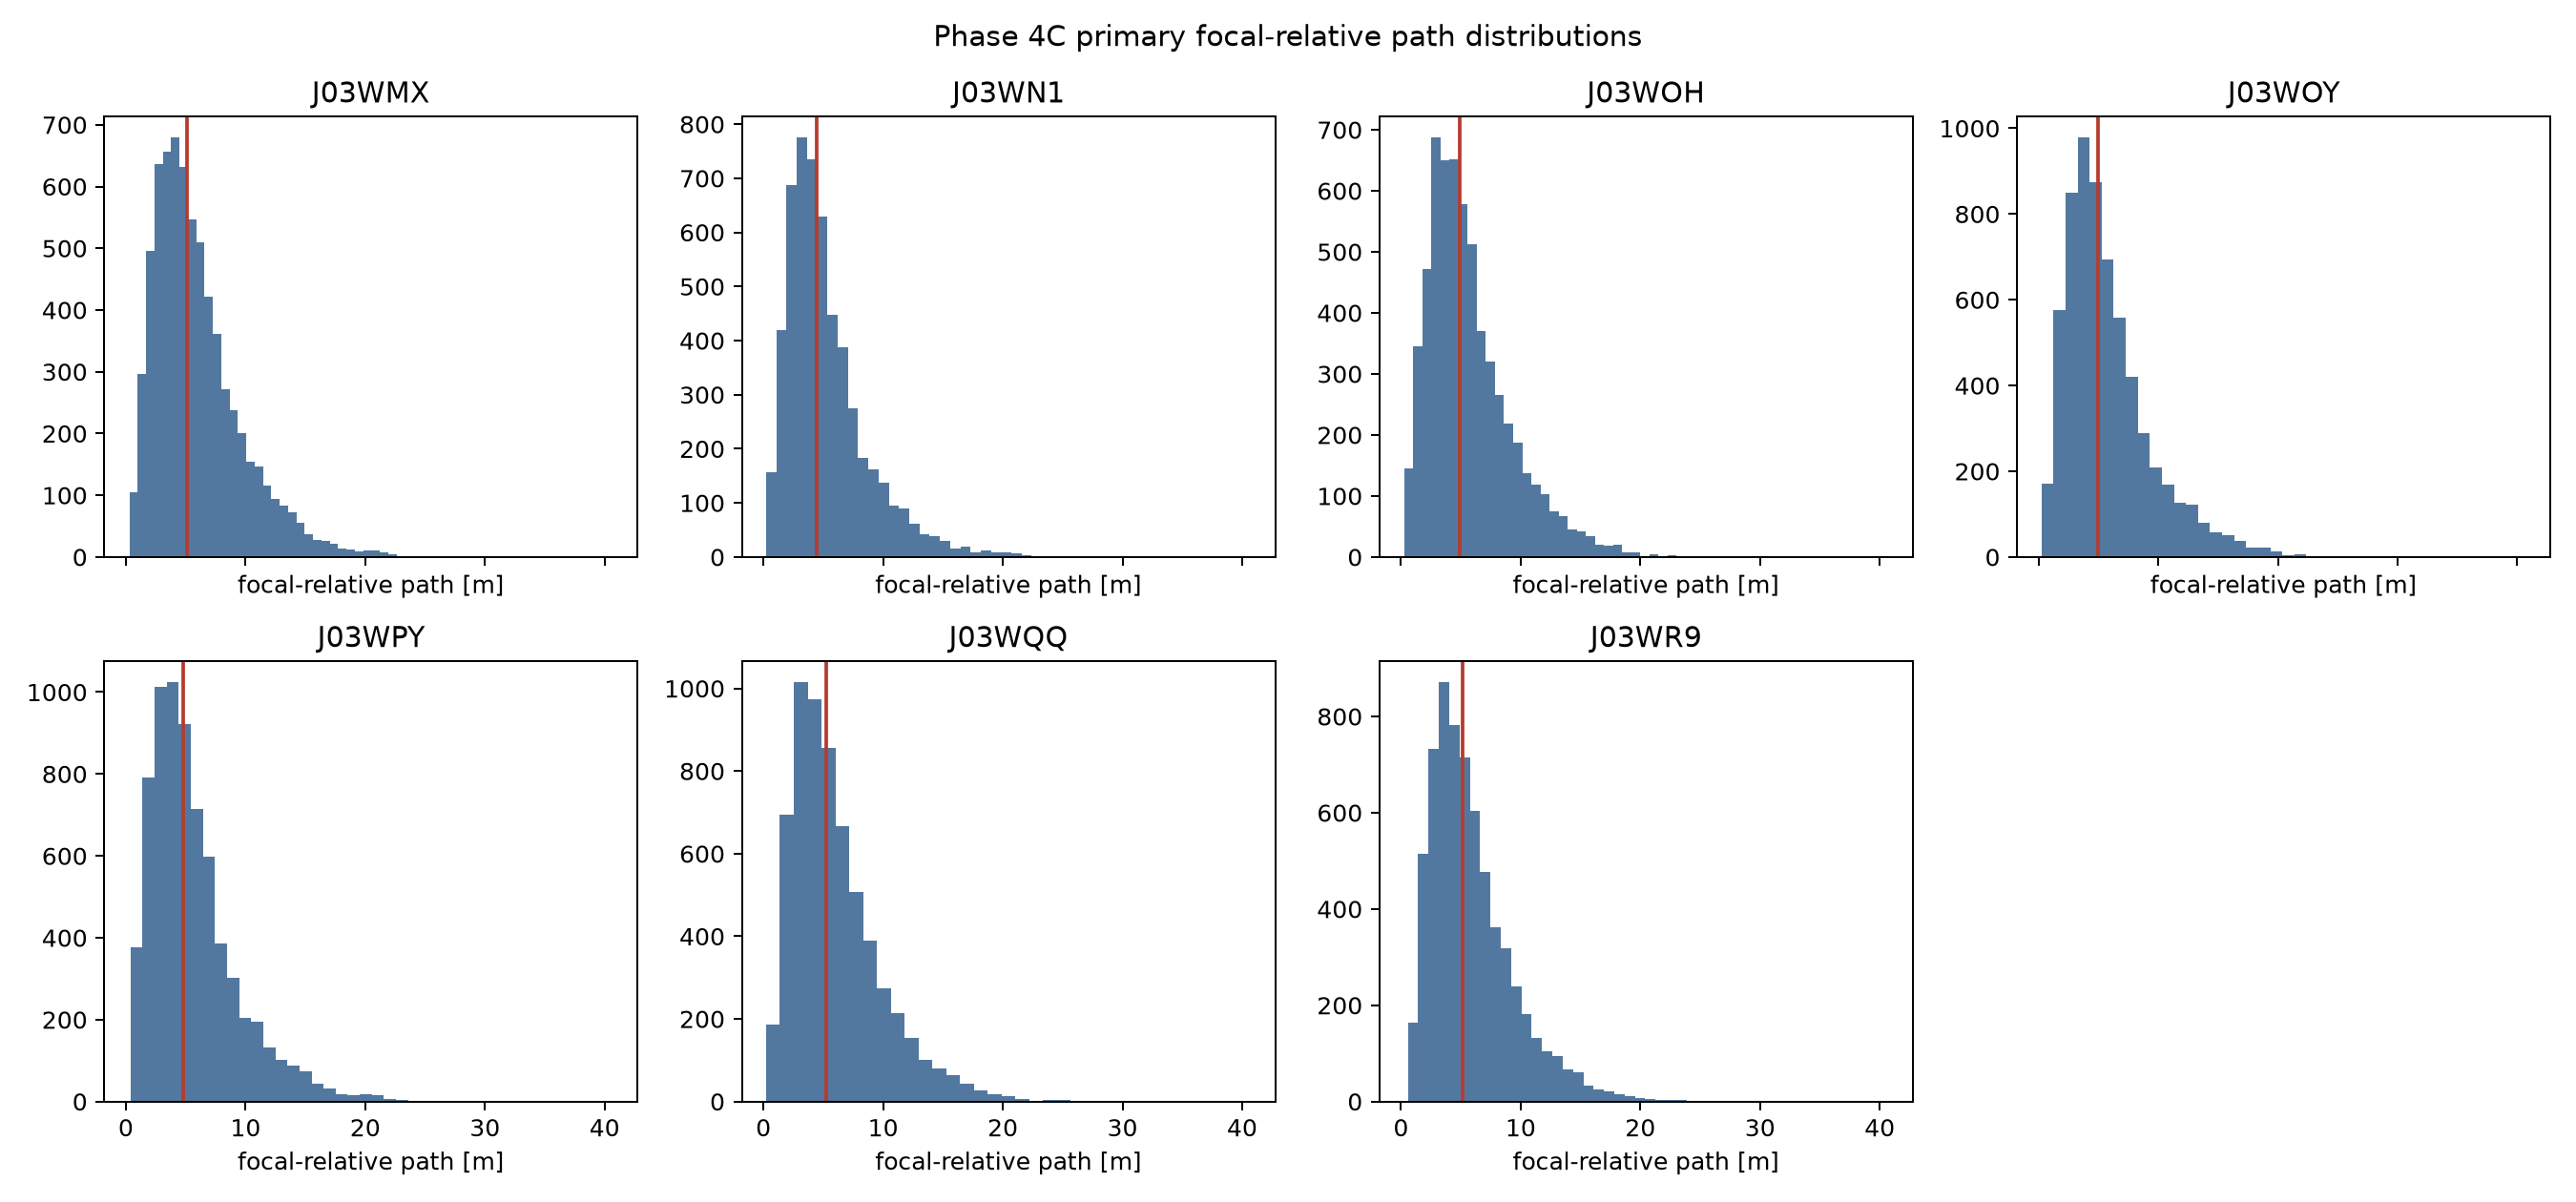

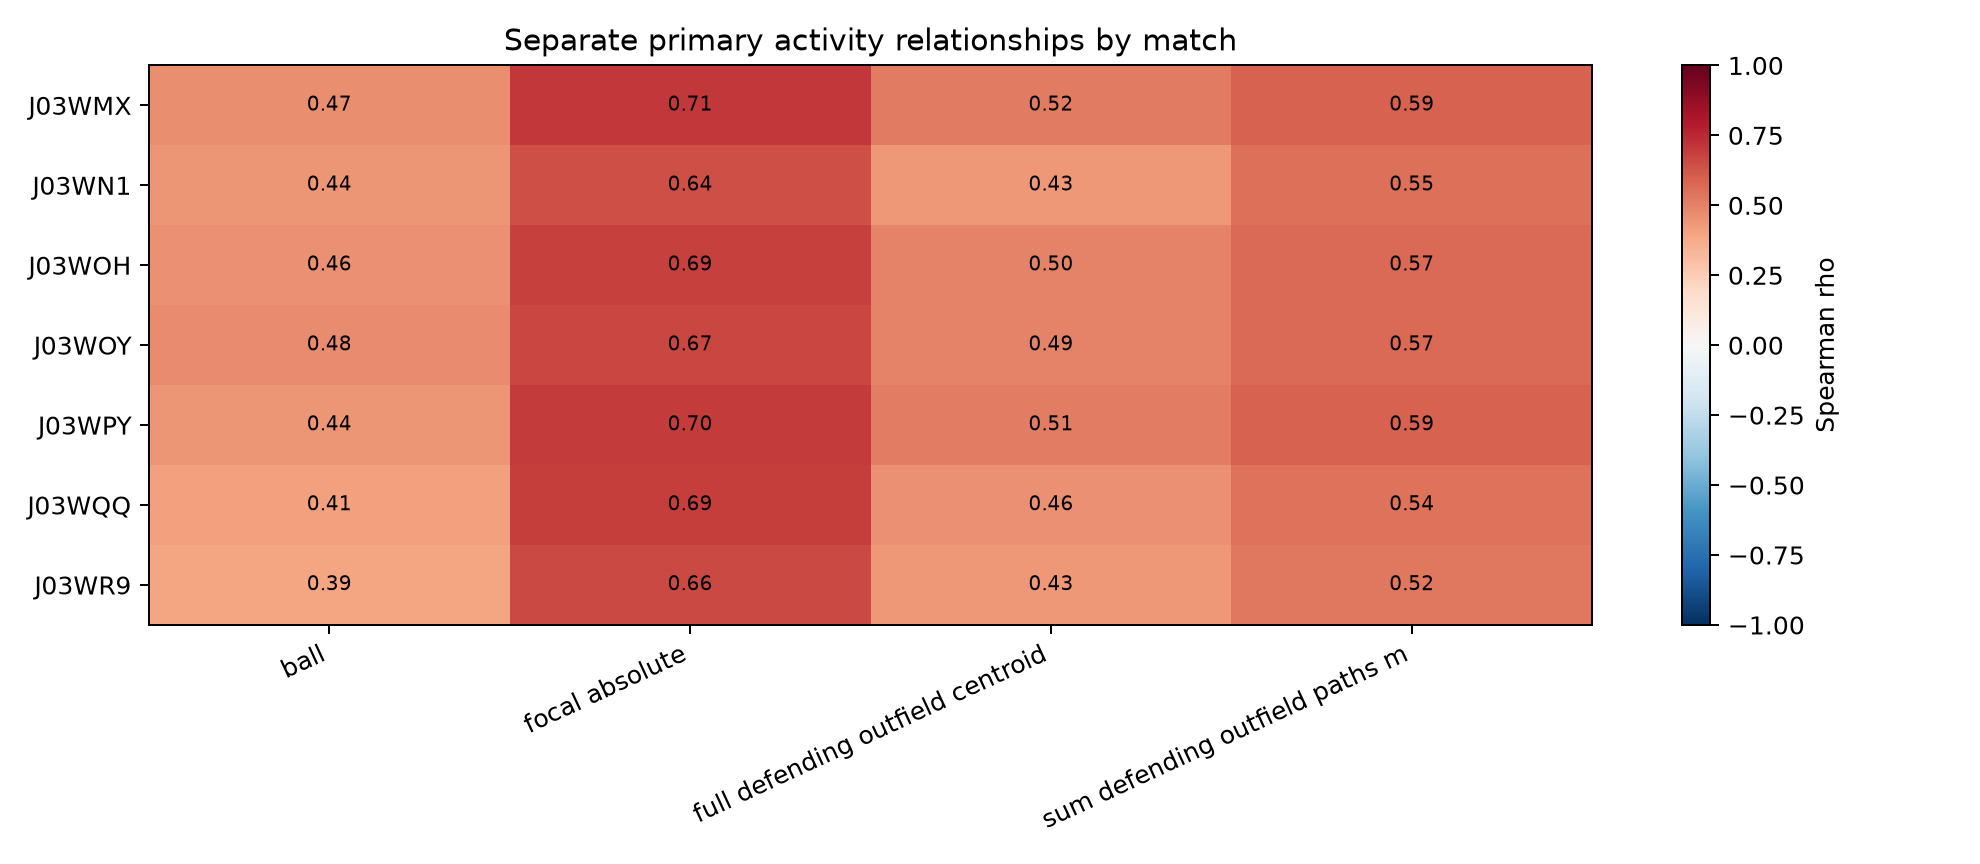

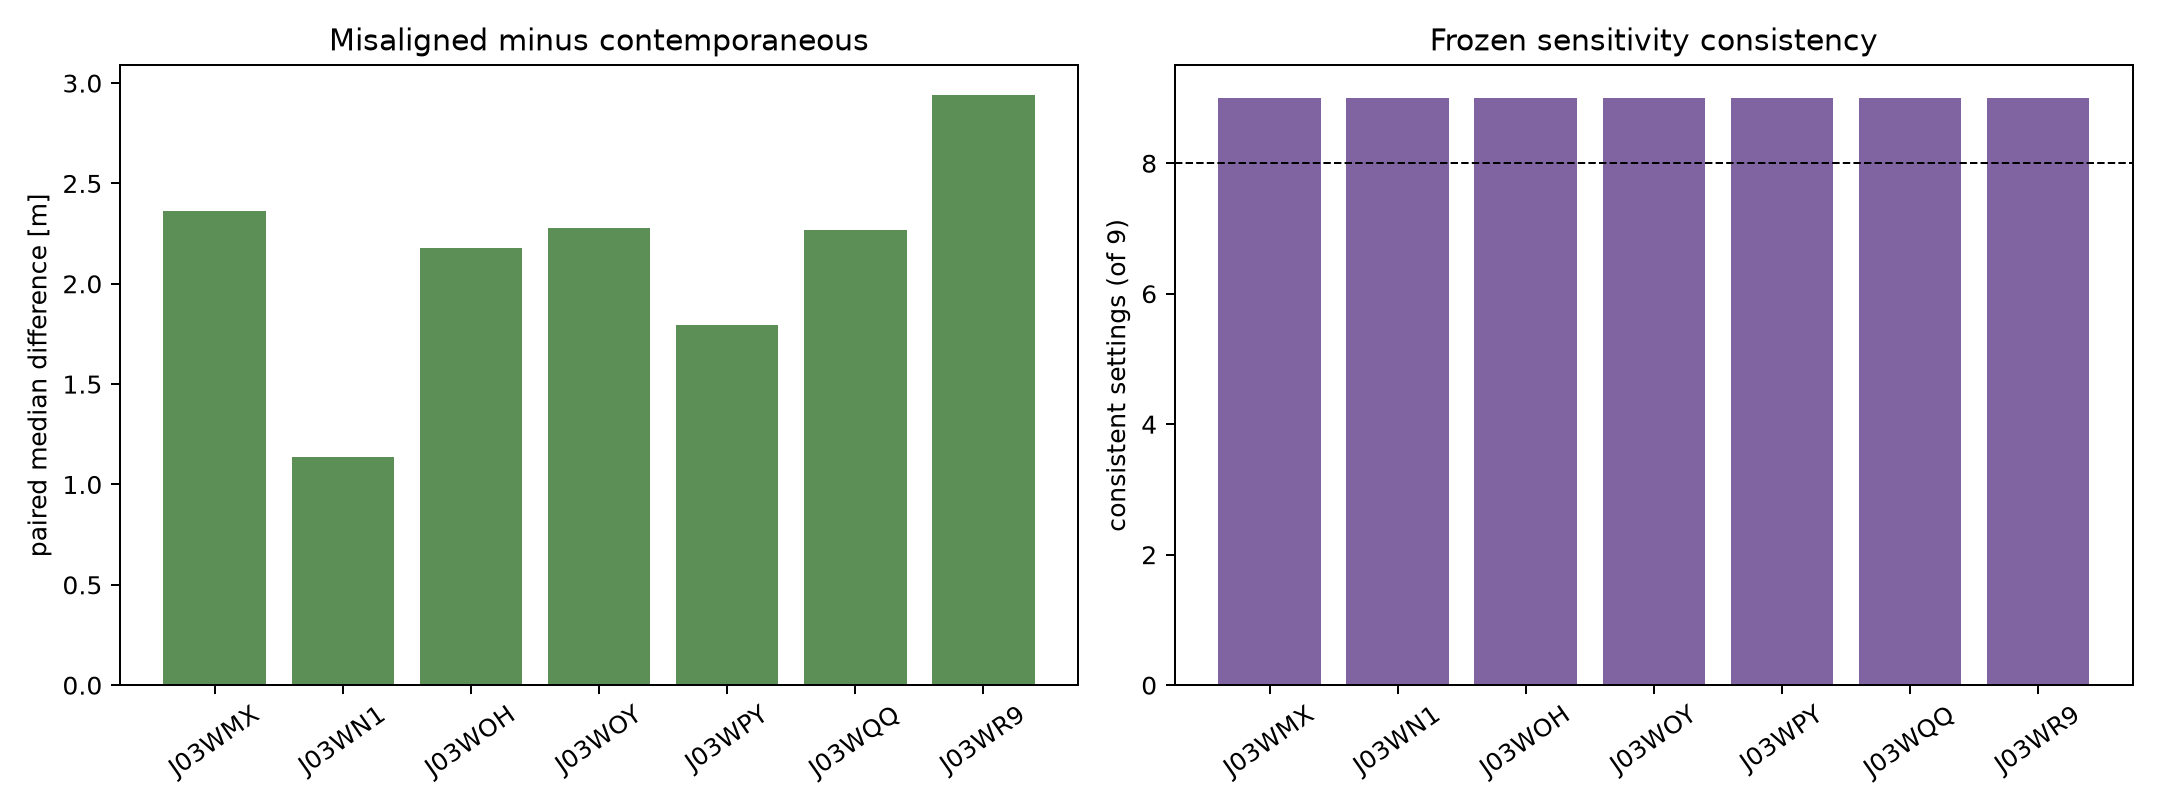

In [6]:
for name in [
    'phase4c_distributions.png',
    'phase4c_activity_relationships.png',
    'phase4c_controls_and_sensitivity.png',
]:
    display(Image(filename=str(FIG / name)))

## Frozen classification and claim boundary

The frozen classification is **A — strong external replication**: all seven usable matches satisfy the core replication criteria, with no material sensitivity or control contradiction. This advances focal departure from held-out validation to external replication as a geometric primitive. It does not advance defensive response or relational reconfiguration beyond unvalidated hypotheses, and it does not attach tactical meaning, attribution, or value to the measure.

In [7]:
assert classification['category'] == 'A'
assert len(match_summary) == 7
assert sensitivity.shape[0] == 7
assert translation['pass'].all()
print(f"{classification['category']} — {classification['label']}")
print('Protocol SHA-256:', manifest['protocol_sha256_before_execution'])

A — strong external replication
Protocol SHA-256: 6e1711ba681bce3c843cde9803758ca68428f2a84e6b25454d9d866cee5dea59
